# Trigonometric Functions — Lecture 6
## Product-to-Sum · Sum-to-Product (C & D) Formulae · Questions

**Source:** [Trigonometric Functions 6 | Product to Sum Formulae | Sum to Product Formulae | Questions](https://www.youtube.com/watch?v=ELNEuojJHgM&list=PLF_7kfnwLFCGWE2w0BsarSM9mbBJMrdRL&index=6), Physics Wallah (Class 11), about 52 min

**Prerequisite:** Lecture 5 (product-to-sum formulae).

### What this lecture covers
1. Recap of the product-to-sum formulae
2. **Sum-to-product ("C & D") formulae**, derived by reversing product-to-sum
3. Questions:
   - If $A + B = \frac{\pi}{4}$, then $(1+\tan A)(1+\tan B) = 2$, plus the homework $\prod(1 + \tan k^\circ)$
   - $\dfrac{\sin A + \sin B}{\cos B - \cos A} = \cot\dfrac{A - B}{2}$
   - $\sin 50^\circ - \sin 70^\circ + \sin 10^\circ = 0$
   - $\sin\frac{\theta}{2}\sin\frac{7\theta}{2} + \sin\frac{3\theta}{2}\sin\frac{11\theta}{2} = \sin 2\theta\sin 5\theta$
   - $\dfrac{\cos\theta - \sin\theta}{\cos\theta + \sin\theta} = \tan\left(\frac{\pi}{4} - \theta\right)$
   - $\dfrac{\sin A + \sin 3A + \sin 5A + \sin 7A}{\cos A + \cos 3A + \cos 5A + \cos 7A} = \tan 4A$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Same look as the earlier lectures
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
d = np.deg2rad
rng = np.random.default_rng(6)

def verify(name, lhs, rhs):
    ok = np.isfinite(lhs) & np.isfinite(rhs) & (np.abs(lhs) < 1e6)
    good = np.isclose(lhs[ok], rhs[ok], rtol=1e-6, atol=1e-9)
    print(f"{name}:  {good.mean()*100:.2f}% of {ok.sum():,} samples agree "
          f"(max |LHS − RHS| = {np.max(np.abs(lhs[ok] - rhs[ok])):.1e})")

def broken(y, jump=8):
    # Break a curve at vertical asymptotes so matplotlib doesn't join the branches
    y = np.array(y, dtype=float); y[np.abs(np.diff(np.r_[y[0], y])) > jump] = np.nan; return y
print("ready")

ready


---
## 1. Recap: Product-to-Sum (and Difference)

| Product | Sum / difference |
|---|---|
| $2\sin A\cos B$ | $\sin(A+B) + \sin(A-B)$ |
| $2\cos A\sin B$ | $\sin(A+B) - \sin(A-B)$ |
| $2\cos A\cos B$ | $\cos(A+B) + \cos(A-B)$ |
| $2\sin A\sin B$ | $\cos(A-B) - \cos(A+B)$, with $\cos(A-B)$ **first** |

The left side is a **product** and the right side is a **sum or difference**, hence the name.

---
## 2. Sum-to-Product: The "C & D" Formulae

**Idea:** read the product-to-sum formulas **backwards**. Take
$$2\sin A\cos B = \sin(A+B) + \sin(A-B)$$
and rename the angles on the right:
$$C = A + B, \qquad D = A - B$$

Adding and subtracting these two equations recovers $A$ and $B$:
$$C + D = 2A \;\Rightarrow\; A = \frac{C + D}{2}, \qquad C - D = 2B \;\Rightarrow\; B = \frac{C - D}{2}$$

Substituting turns the formula around:
$$\sin C + \sin D = 2\sin\frac{C+D}{2}\cos\frac{C-D}{2}$$

Doing the same with the other three product-to-sum formulas gives the whole family:

$$\boxed{\sin C + \sin D = 2\sin\frac{C+D}{2}\cos\frac{C-D}{2}}$$
$$\boxed{\sin C - \sin D = 2\cos\frac{C+D}{2}\sin\frac{C-D}{2}}$$
$$\boxed{\cos C + \cos D = 2\cos\frac{C+D}{2}\cos\frac{C-D}{2}}$$
$$\boxed{\cos C - \cos D = -2\sin\frac{C+D}{2}\sin\frac{C-D}{2}}$$

These are the **sum-to-product** (or **difference-to-product**) formulae, also called the **C & D formulae**.

**How to remember them (from the lecture):**
- The first factor always uses the **half-sum** $\frac{C+D}{2}$, and the second always uses the **half-difference** $\frac{C-D}{2}$.
- $\sin + \sin$ gives **sin · cos**. $\sin - \sin$ gives **cos · sin**.
- $\cos + \cos$ gives **cos · cos**. $\cos - \cos$ gives **sin · sin** with a **minus sign**. People forget that minus, so don't.

**When to use which:**
- Given a **product** and need a sum: use product-to-sum.
- Given a **sum/difference** and need a product: use C & D.

In [2]:
C, D = rng.uniform(-2*np.pi, 2*np.pi, (2, 100_000))
h, k = (C + D)/2, (C - D)/2
verify("sin C + sin D =  2 sin½(C+D) cos½(C−D)", np.sin(C) + np.sin(D),  2*np.sin(h)*np.cos(k))
verify("sin C − sin D =  2 cos½(C+D) sin½(C−D)", np.sin(C) - np.sin(D),  2*np.cos(h)*np.sin(k))
verify("cos C + cos D =  2 cos½(C+D) cos½(C−D)", np.cos(C) + np.cos(D),  2*np.cos(h)*np.cos(k))
verify("cos C − cos D = −2 sin½(C+D) sin½(C−D)", np.cos(C) - np.cos(D), -2*np.sin(h)*np.sin(k))

sin C + sin D =  2 sin½(C+D) cos½(C−D):  100.00% of 100,000 samples agree (max |LHS − RHS| = 1.0e-15)
sin C − sin D =  2 cos½(C+D) sin½(C−D):  100.00% of 100,000 samples agree (max |LHS − RHS| = 1.1e-15)
cos C + cos D =  2 cos½(C+D) cos½(C−D):  100.00% of 100,000 samples agree (max |LHS − RHS| = 1.1e-15)
cos C − cos D = −2 sin½(C+D) sin½(C−D):  100.00% of 100,000 samples agree (max |LHS − RHS| = 8.9e-16)


### What sum-to-product looks like *(extra: beats)*
Add two waves with **close** frequencies, $\cos 10t + \cos 12t$. C & D says this equals
$$2\cos 11t\cdot\cos t$$
a fast wave at the **average** frequency ($11$), multiplied by a slow envelope at **half the difference** ($1$). That is exactly the "beat" you hear when two nearly-tuned notes are played together.

Lecture 5's figure went from product to sum. This one goes the other way.

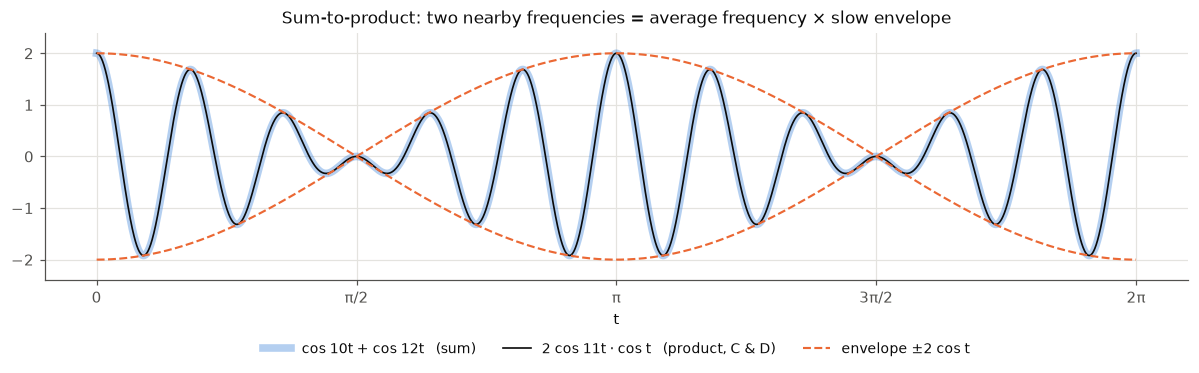

In [3]:
t = np.linspace(0, 2*np.pi, 3000)
s = np.cos(10*t) + np.cos(12*t)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(t, s, color=BLUE, lw=5, alpha=0.35, label="cos 10t + cos 12t   (sum)")
ax.plot(t, 2*np.cos(11*t)*np.cos(t), color=INK, lw=1.1, label="2 cos 11t · cos t   (product, C & D)")
ax.plot(t, 2*np.cos(t), color=ORANGE, lw=1.4, ls="--", label="envelope ±2 cos t")
ax.plot(t, -2*np.cos(t), color=ORANGE, lw=1.4, ls="--")
ax.set_xticks(np.arange(0, 2.01, 0.5)*np.pi, ["0", "π/2", "π", "3π/2", "2π"]); ax.set_xlabel("t")
ax.set_ylim(-2.4, 2.4)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=9)
ax.set_title("Sum-to-product: two nearby frequencies = average frequency × slow envelope", fontsize=11)
plt.tight_layout(); plt.show()

---
## 3. Questions

> The lecturer's definition of a solution: *build a path from what is **given** to what is **asked**.*

### Q1. If $A + B = \frac{\pi}{4}$, find $(1 + \tan A)(1 + \tan B)$.
Take $\tan$ of both sides of $A + B = \frac{\pi}{4}$:
$$\frac{\tan A + \tan B}{1 - \tan A\tan B} = \tan\frac{\pi}{4} = 1$$
Cross-multiply:
$$\tan A + \tan B = 1 - \tan A\tan B \;\Longrightarrow\; \tan A + \tan B + \tan A\tan B = 1$$

**Add 1 to both sides.** This makes the left side match the target:
$$1 + \tan A + \tan B + \tan A\tan B = 2$$
Factor by grouping, taking $(1 + \tan A)$ common:
$$(1 + \tan A) + \tan B(1 + \tan A) = (1 + \tan A)(1 + \tan B) = \boxed{2}$$

> **JEE tip:** remember it as a result. *If $A + B = 45^\circ$, then $(1 + \tan A)(1 + \tan B) = 2$.*

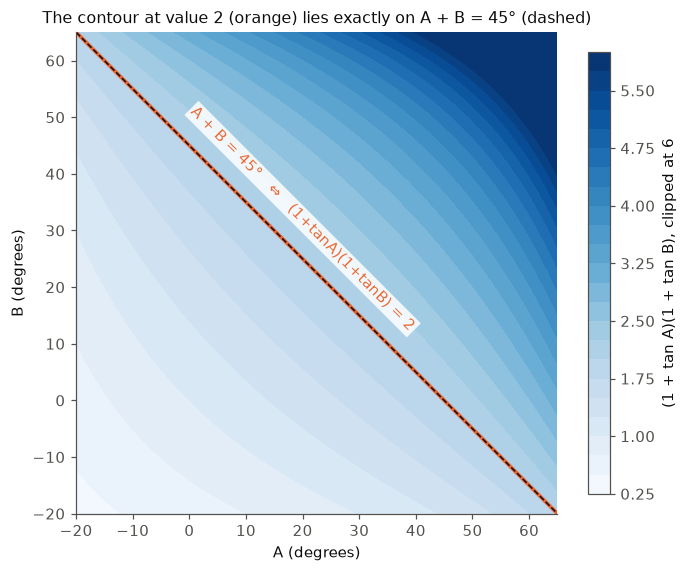

In [4]:
# Heat map of (1 + tanA)(1 + tanB): the level set "= 2" is exactly the line A + B = 45°
Ad = np.linspace(-20, 65, 400); Bd = np.linspace(-20, 65, 400)
AA, BB = np.meshgrid(Ad, Bd)
P = (1 + np.tan(d(AA)))*(1 + np.tan(d(BB)))
fig, ax = plt.subplots(figsize=(6.4, 5.6)); ax.grid(False)
im = ax.contourf(AA, BB, np.clip(P, 0, 6), levels=24, cmap="Blues")
cs = ax.contour(AA, BB, P, levels=[2], colors=[ORANGE], linewidths=2.5)
ax.plot(Ad, 45 - Ad, color=INK, lw=1, ls="--")
ax.text(20, 32, "A + B = 45°   ⇔   (1+tanA)(1+tanB) = 2", color=ORANGE, fontsize=10, rotation=-45,
        ha="center", va="center", bbox=dict(fc="white", ec="none", pad=1.5, alpha=0.85))
ax.set_xlim(-20, 65); ax.set_ylim(-20, 65); ax.set_aspect("equal")
ax.set_xlabel("A (degrees)"); ax.set_ylabel("B (degrees)")
fig.colorbar(im, ax=ax, shrink=0.8, label="(1 + tan A)(1 + tan B), clipped at 6")
ax.set_title("The contour at value 2 (orange) lies exactly on A + B = 45° (dashed)", fontsize=10.5)
plt.tight_layout(); plt.show()

**Homework from the lecture:** find $(1 + \tan 1^\circ)(1 + \tan 2^\circ)(1 + \tan 3^\circ)\cdots$, using Q1.

The captions don't make clear whether the product stops at $44^\circ$ or $45^\circ$. Here are both:

<details>
<summary>Answer (open after attempting)</summary>

Pair the factors whose angles add to $45^\circ$: $(1^\circ, 44^\circ), (2^\circ, 43^\circ), \dots, (22^\circ, 23^\circ)$. That is **22 pairs**, and each pair multiplies to $2$:
$$\prod_{k=1}^{44}(1 + \tan k^\circ) = 2^{22}$$
Including $k = 45^\circ$ adds one more factor $1 + \tan 45^\circ = 2$, giving $2^{23}$.
</details>

∏(1 + tan k°), k = 1…44 = 4,194,304.0000   2^22 = 4,194,304
∏(1 + tan k°), k = 1…45 = 8,388,608.0000   2^23 = 8,388,608


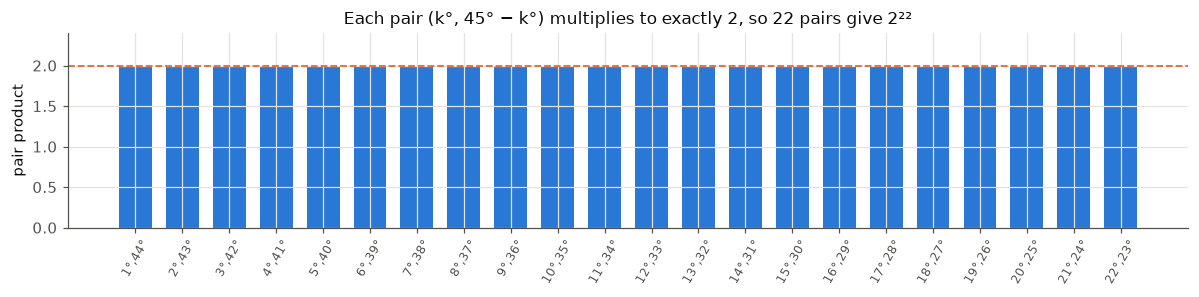

In [5]:
k = np.arange(1, 45)
prod44 = np.prod(1 + np.tan(d(k)))
print(f"∏(1 + tan k°), k = 1…44 = {prod44:,.4f}   2^22 = {2**22:,}")
print(f"∏(1 + tan k°), k = 1…45 = {prod44*2:,.4f}   2^23 = {2**23:,}")

# Each pair contributes exactly one doubling
pairs = [(i, 45 - i) for i in range(1, 23)]
vals = [(1 + np.tan(d(a)))*(1 + np.tan(d(b))) for a, b in pairs]
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.bar(range(22), vals, color=BLUE, width=0.7)
ax.axhline(2, color=ORANGE, lw=1.2, ls="--")
ax.set_xticks(range(22), [f"{a}°,{b}°" for a, b in pairs], rotation=60, fontsize=8)
ax.set_ylim(0, 2.4); ax.set_ylabel("pair product")
ax.set_title("Each pair (k°, 45° − k°) multiplies to exactly 2, so 22 pairs give 2²²", fontsize=11)
plt.tight_layout(); plt.show()

### Q2. Prove $\dfrac{\sin A + \sin B}{\cos B - \cos A} = \cot\dfrac{A - B}{2}$
Numerator, using $\sin C + \sin D$:
$$\sin A + \sin B = 2\sin\frac{A+B}{2}\cos\frac{A-B}{2}$$
Denominator, using $\cos C - \cos D$ with $C = B$ and $D = A$:
$$\cos B - \cos A = -2\sin\frac{B+A}{2}\sin\frac{B-A}{2}$$

Divide. The common factor $2\sin\frac{A+B}{2}$ cancels:
$$\text{LHS} = \frac{\cos\frac{A-B}{2}}{-\sin\frac{B-A}{2}}$$

**Negative-angle rules (Lecture 4):** $\cos$ swallows a minus sign, and $\sin$ pushes it out. Since $\frac{B-A}{2} = -\frac{A-B}{2}$:
$$-\sin\frac{B-A}{2} = -\left(-\sin\frac{A-B}{2}\right) = \sin\frac{A-B}{2}$$
$$\text{LHS} = \frac{\cos\frac{A-B}{2}}{\sin\frac{A-B}{2}} = \cot\frac{A-B}{2} = \text{RHS} \quad\blacksquare$$

In [6]:
A, B = rng.uniform(-np.pi, np.pi, (2, 100_000))
verify("Q2", (np.sin(A) + np.sin(B))/(np.cos(B) - np.cos(A)), 1/np.tan((A - B)/2))

Q2:  100.00% of 100,000 samples agree (max |LHS − RHS| = 5.9e-07)


### Q3. Prove $\sin 50^\circ - \sin 70^\circ + \sin 10^\circ = 0$
**Thought process:** terms simplify against each other only when they are the "same kind", like mangoes with mangoes. $50^\circ$, $70^\circ$ and $10^\circ$ look unrelated, so rewrite them around a **standard angle**:
$$50^\circ = 60^\circ - 10^\circ, \qquad 70^\circ = 60^\circ + 10^\circ$$

Using $\sin(A-B) - \sin(A+B) = -2\cos A\sin B$ (either expand both terms, or apply C & D):
$$\sin(60^\circ - 10^\circ) - \sin(60^\circ + 10^\circ) = -2\cos 60^\circ\sin 10^\circ = -2\cdot\tfrac12\sin 10^\circ = -\sin 10^\circ$$

So
$$\text{LHS} = -\sin 10^\circ + \sin 10^\circ = 0 \quad\blacksquare$$

**This is not special to $10^\circ$.** The same steps show that for **every** $x$:
$$\sin(60^\circ - x) - \sin(60^\circ + x) + \sin x = 0$$

sin50° − sin70° + sin10° = 2.78e-17


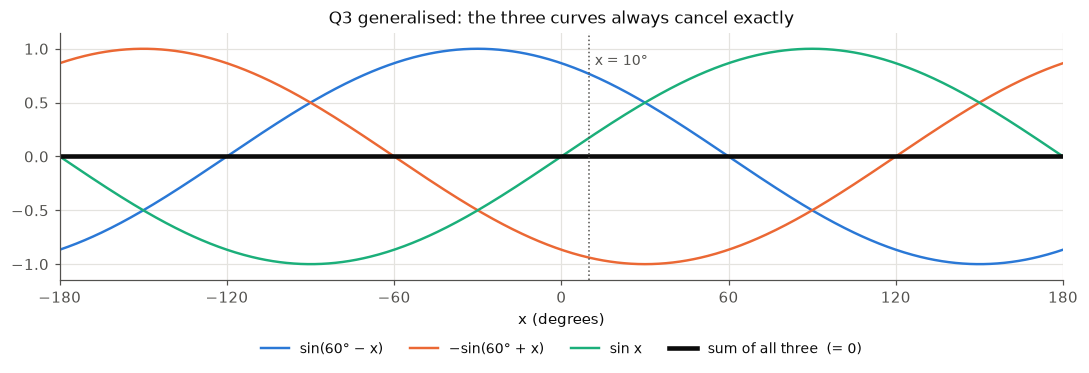

In [7]:
print(f"sin50° − sin70° + sin10° = {np.sin(d(50)) - np.sin(d(70)) + np.sin(d(10)):.2e}")

x = np.linspace(-180, 180, 721); xr = d(x)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(x, np.sin(d(60) - xr), color=BLUE, lw=1.6, label="sin(60° − x)")
ax.plot(x, -np.sin(d(60) + xr), color=ORANGE, lw=1.6, label="−sin(60° + x)")
ax.plot(x, np.sin(xr), color=AQUA, lw=1.6, label="sin x")
ax.plot(x, np.sin(d(60) - xr) - np.sin(d(60) + xr) + np.sin(xr), color=INK, lw=3, label="sum of all three  (= 0)")
ax.axvline(10, color=INK2, lw=1, ls=":"); ax.text(12, 0.85, "x = 10°", fontsize=9, color=INK2)
ax.set_xticks(range(-180, 181, 60)); ax.set_xlim(-180, 180); ax.set_ylim(-1.15, 1.15); ax.set_xlabel("x (degrees)")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=9)
ax.set_title("Q3 generalised: the three curves always cancel exactly", fontsize=11)
plt.tight_layout(); plt.show()

### Q4. Prove $\sin\dfrac{\theta}{2}\sin\dfrac{7\theta}{2} + \sin\dfrac{3\theta}{2}\sin\dfrac{11\theta}{2} = \sin 2\theta\sin 5\theta$
**First look:** no formula applies directly. **Trick:** multiply and divide by 2 to create $2\sin A\sin B$:
$$\text{LHS} = \frac12\left[2\sin\frac{7\theta}{2}\sin\frac{\theta}{2} + 2\sin\frac{11\theta}{2}\sin\frac{3\theta}{2}\right]$$

Product to sum, $2\sin A\sin B = \cos(A-B) - \cos(A+B)$:
$$= \frac12\Big[(\cos 3\theta - \cos 4\theta) + (\cos 4\theta - \cos 7\theta)\Big] = \frac12(\cos 3\theta - \cos 7\theta)$$

The $\cos 4\theta$ terms cancel. Now apply C & D, $\cos C - \cos D = -2\sin\frac{C+D}{2}\sin\frac{C-D}{2}$:
$$= \frac12\cdot\left(-2\sin 5\theta\sin(-2\theta)\right) = \sin 5\theta\sin 2\theta \quad\blacksquare$$
($\sin(-2\theta) = -\sin 2\theta$, and the two minus signs make a plus.)

> **Lesson:** when no formula fits, see whether a small change, like $\times 2 \div 2$, makes one fit.

Q4:  100.00% of 100,000 samples agree (max |LHS − RHS| = 2.9e-15)


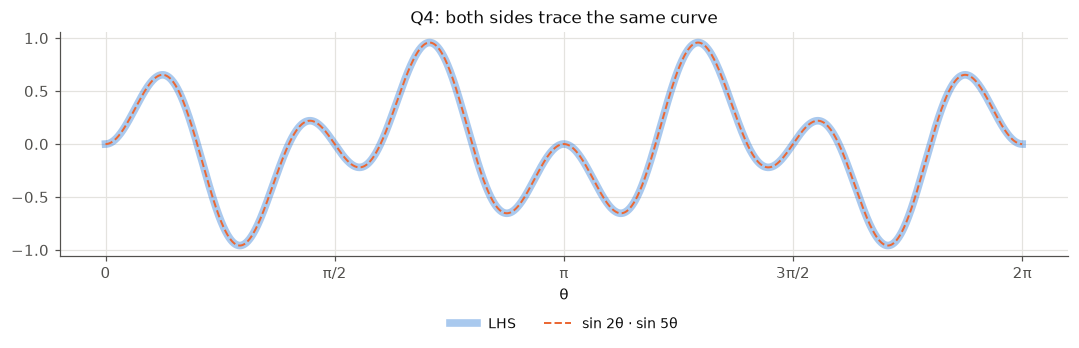

In [8]:
th = rng.uniform(-2*np.pi, 2*np.pi, 100_000)
verify("Q4", np.sin(th/2)*np.sin(7*th/2) + np.sin(3*th/2)*np.sin(11*th/2), np.sin(2*th)*np.sin(5*th))

tg = np.linspace(0, 2*np.pi, 2000)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(tg, np.sin(tg/2)*np.sin(7*tg/2) + np.sin(3*tg/2)*np.sin(11*tg/2), color=BLUE, lw=5, alpha=0.4, label="LHS")
ax.plot(tg, np.sin(2*tg)*np.sin(5*tg), color=ORANGE, lw=1.3, ls="--", label="sin 2θ · sin 5θ")
ax.set_xticks(np.arange(0, 2.01, 0.5)*np.pi, ["0", "π/2", "π", "3π/2", "2π"]); ax.set_xlabel("θ")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22), fontsize=9)
ax.set_title("Q4: both sides trace the same curve", fontsize=11)
plt.tight_layout(); plt.show()

### Q5. Prove $\dfrac{\cos\theta - \sin\theta}{\cos\theta + \sin\theta} = \tan\left(\dfrac{\pi}{4} - \theta\right)$
The target is in terms of $\tan$, so **convert to $\tan$ first** by dividing the numerator and denominator by $\cos\theta$:
$$\text{LHS} = \frac{1 - \tan\theta}{1 + \tan\theta}$$

**Trick:** $1 = \tan\frac{\pi}{4}$, so replace the 1s. Multiplying by $1 = \tan\frac{\pi}{4}$ changes nothing:
$$= \frac{\tan\frac{\pi}{4} - \tan\theta}{1 + \tan\frac{\pi}{4}\tan\theta}$$

This is exactly the expansion of $\tan(A - B)$ with $A = \frac{\pi}{4}$ and $B = \theta$:
$$= \tan\left(\frac{\pi}{4} - \theta\right) \quad\blacksquare$$

> The similar result $\dfrac{1 + \tan\theta}{1 - \tan\theta} = \tan\left(\dfrac{\pi}{4} + \theta\right)$ appears often too.

Q5:  100.00% of 4,000 samples agree (max |LHS − RHS| = 3.0e-10)


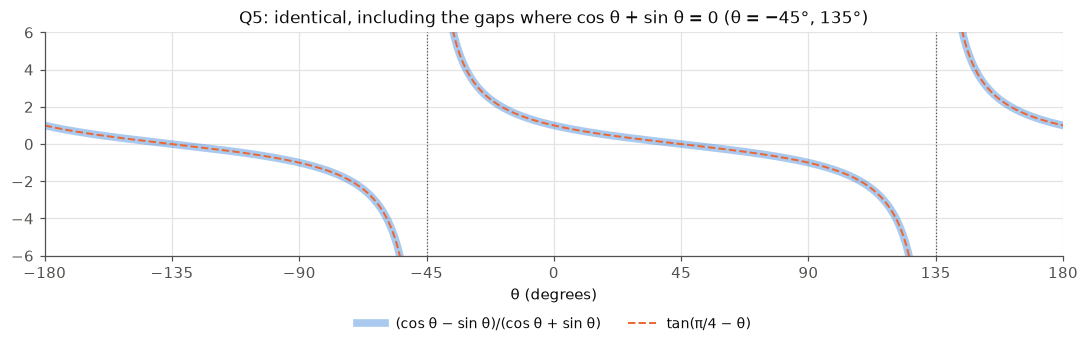

In [9]:
th = np.linspace(-np.pi, np.pi, 4000)
lhs = (np.cos(th) - np.sin(th))/(np.cos(th) + np.sin(th)); rhs = np.tan(np.pi/4 - th)
verify("Q5", lhs, rhs)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(np.rad2deg(th), broken(lhs), color=BLUE, lw=5, alpha=0.4, label="(cos θ − sin θ)/(cos θ + sin θ)")
ax.plot(np.rad2deg(th), broken(rhs), color=ORANGE, lw=1.3, ls="--", label="tan(π/4 − θ)")
for a in (-45, 135): ax.axvline(a, color=INK2, lw=0.8, ls=":")
ax.set_ylim(-6, 6); ax.set_xlim(-180, 180); ax.set_xticks(range(-180, 181, 45)); ax.set_xlabel("θ (degrees)")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22), fontsize=9)
ax.set_title("Q5: identical, including the gaps where cos θ + sin θ = 0 (θ = −45°, 135°)", fontsize=11)
plt.tight_layout(); plt.show()

> **Homework from the lecture:** a short "cutie-pie" question. The lecturer says it has many solutions, the smartest being one or two lines. It was shown only on screen and is **not recoverable from the captions**, so it is left out here.

### Q6. Prove $\dfrac{\sin A + \sin 3A + \sin 5A + \sin 7A}{\cos A + \cos 3A + \cos 5A + \cos 7A} = \tan 4A$
**Pairing strategy (from the lecture):** pair the **largest with the smallest** ($7A$ with $A$) and the two middle ones ($5A$ with $3A$). Their half-sums are then all equal, $\frac{7A + A}{2} = \frac{5A + 3A}{2} = 4A$, which creates a common factor.

Numerator:
$$(\sin 7A + \sin A) + (\sin 5A + \sin 3A) = 2\sin 4A\cos 3A + 2\sin 4A\cos A = 2\sin 4A(\cos 3A + \cos A)$$
Denominator:
$$(\cos 7A + \cos A) + (\cos 5A + \cos 3A) = 2\cos 4A\cos 3A + 2\cos 4A\cos A = 2\cos 4A(\cos 3A + \cos A)$$

Divide. $2(\cos 3A + \cos A)$ cancels:
$$\text{LHS} = \frac{\sin 4A}{\cos 4A} = \tan 4A \quad\blacksquare$$
($\cos(-3A) = \cos 3A$ and $\cos(-A) = \cos A$, so the order inside the half-differences doesn't matter.)

Q6:  100.00% of 6,000 samples agree (max |LHS − RHS| = 9.3e-09)


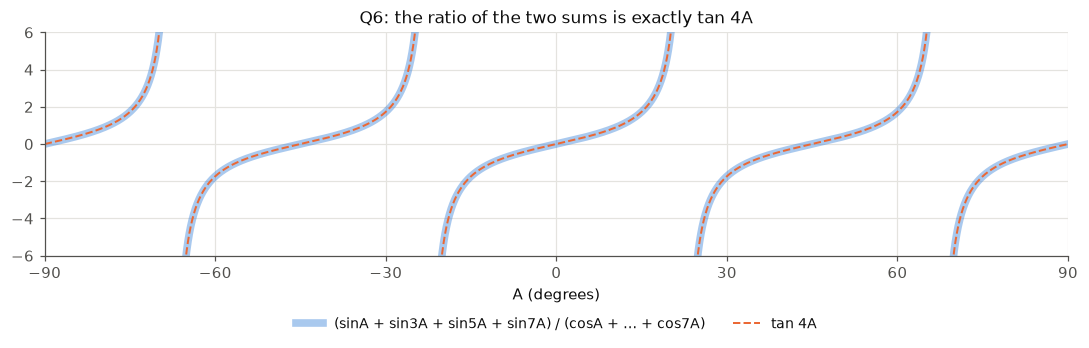

In [10]:
A = np.linspace(-np.pi/2, np.pi/2, 6000)
num = np.sin(A) + np.sin(3*A) + np.sin(5*A) + np.sin(7*A)
den = np.cos(A) + np.cos(3*A) + np.cos(5*A) + np.cos(7*A)
verify("Q6", num/den, np.tan(4*A))
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(np.rad2deg(A), broken(num/den), color=BLUE, lw=5, alpha=0.4, label="(sinA + sin3A + sin5A + sin7A) / (cosA + … + cos7A)")
ax.plot(np.rad2deg(A), broken(np.tan(4*A)), color=ORANGE, lw=1.3, ls="--", label="tan 4A")
ax.set_ylim(-6, 6); ax.set_xlim(-90, 90); ax.set_xticks(range(-90, 91, 30)); ax.set_xlabel("A (degrees)")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22), fontsize=9)
ax.set_title("Q6: the ratio of the two sums is exactly tan 4A", fontsize=11)
plt.tight_layout(); plt.show()

> **Last homework from the lecture:** a question involving $\Sigma$ notation, which the lecturer will explain next time. It was also shown only on screen and is **not recoverable from the captions**.

---
## 4. Summary

**C & D (sum-to-product) formulae**
| Sum / difference | Product |
|---|---|
| $\sin C + \sin D$ | $2\sin\frac{C+D}{2}\cos\frac{C-D}{2}$ |
| $\sin C - \sin D$ | $2\cos\frac{C+D}{2}\sin\frac{C-D}{2}$ |
| $\cos C + \cos D$ | $2\cos\frac{C+D}{2}\cos\frac{C-D}{2}$ |
| $\cos C - \cos D$ | $-2\sin\frac{C+D}{2}\sin\frac{C-D}{2}$ |

**Techniques**
1. Decide the destination, then choose the formula: product↔sum, or convert to $\tan$.
2. Rewrite awkward angles around standard ones ($50^\circ = 60^\circ - 10^\circ$).
3. If no formula fits, adjust: multiply and divide by 2, or write $1 = \tan\frac{\pi}{4}$.
4. To add several sines or cosines, pair the largest with the smallest so the half-sums match.
5. Adding a constant to both sides can complete a factorisation (Q1).

**Results worth memorising**
- $A + B = 45^\circ \Rightarrow (1 + \tan A)(1 + \tan B) = 2$
- $\dfrac{1 - \tan\theta}{1 + \tan\theta} = \tan\left(\frac{\pi}{4} - \theta\right)$ and $\dfrac{1 + \tan\theta}{1 - \tan\theta} = \tan\left(\frac{\pi}{4} + \theta\right)$

### Practice
1. Write $\sin 5x + \sin 3x$ and $\cos 7x - \cos x$ as products.
2. Prove $\dfrac{\sin 5x - \sin 3x}{\cos 5x + \cos 3x} = \tan x$.
3. Prove $\cos 20^\circ + \cos 100^\circ + \cos 140^\circ = 0$.
4. Prove $\sin 10^\circ + \sin 20^\circ + \sin 40^\circ + \sin 50^\circ = \sin 70^\circ + \sin 80^\circ$.

In [11]:
# Checks for the practice set
x = rng.uniform(-1.5, 1.5, 50_000)
verify("P1a  sin5x + sin3x = 2 sin4x cos x", np.sin(5*x) + np.sin(3*x), 2*np.sin(4*x)*np.cos(x))
verify("P1b  cos7x − cos x = −2 sin4x sin3x", np.cos(7*x) - np.cos(x), -2*np.sin(4*x)*np.sin(3*x))
verify("P2", (np.sin(5*x) - np.sin(3*x))/(np.cos(5*x) + np.cos(3*x)), np.tan(x))
s_, c_ = lambda a: np.sin(d(a)), lambda a: np.cos(d(a))
print(f"P3  cos20° + cos100° + cos140° = {c_(20) + c_(100) + c_(140):.2e}")
print(f"P4  LHS − RHS = {s_(10) + s_(20) + s_(40) + s_(50) - s_(70) - s_(80):.2e}")

P1a  sin5x + sin3x = 2 sin4x cos x:  100.00% of 50,000 samples agree (max |LHS − RHS| = 7.8e-16)
P1b  cos7x − cos x = −2 sin4x sin3x:  100.00% of 50,000 samples agree (max |LHS − RHS| = 1.2e-15)
P2:  100.00% of 50,000 samples agree (max |LHS − RHS| = 2.1e-12)
P3  cos20° + cos100° + cos140° = 2.22e-16
P4  LHS − RHS = -2.22e-16
